# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Big Data** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Examples on Storage Solutions (PostgreSQL)** </center>
---
**Profesor**: Pablo Camarillo Ramirez

**Team**: Paola Covarrubias, Dario Gacía, Guillermo Romero

# Create SparkSession

In [1]:
!ls /opt/spark/work-dir/notebooks/jars/postgresql-42.7.8.jar

/opt/spark/work-dir/notebooks/jars/postgresql-42.7.8.jar


In [22]:
from SparkUtils import SparkUtils

import matplotlib.pyplot as plt
import pyspark.sql.functions as F

In [3]:
# create Spark session
MASTER_URL = "spark://spark-master:7077"
APP_NAME = "Examples on storage solutions with PosgreSQL"
SPARK_JARS = "/opt/spark/work-dir/notebooks/jars/postgresql-42.7.8.jar"

spark = SparkUtils(MASTER_URL, APP_NAME, SPARK_JARS)._spark

spark

26/03/12 00:47:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


# Create DataFrames

In [9]:
movies_columns = [
    ("MovieID", "int"),
    ("Title", "string"),
    ("Genre", "string"),
    ("ReleaseYear", "int"),
    ("ReleaseDate_Str", "string"),
    ("Country", "string"),
    ("BudgetUSD", "float"),
    ("US_BoxOfficeUSD", "float"),
    ("Global_BoxOfficeUSD", "float"),
    ("Opening_Day_SalesUSD", "float"),
    ("One_Week_SalesUSD", "float"),
    ("IMDbRating", "float"),
    ("RottenTomatoesScore", "float"),
    ("NumVotesIMDb", "int"),
    ("NumVotesRT", "int"),
    ("Director", "string"),
    ("LeadActor", "string")
]

movies_schema = SparkUtils.generate_schema(movies_columns)

movies_date_str_df = spark.read\
    .option("header", "true")\
    .schema(movies_schema)\
    .csv("/opt/spark/work-dir/data/movies")\

movies_df = movies_date_str_df.withColumn("ReleaseDate", F.to_date("ReleaseDate_Str", "dd-MM-yyyy")).drop("ReleaseDate_Str")
grouped_movies_df = movies_df.groupBy("Genre").count().orderBy(F.col("count"), ascending=False)
grouped_movies_df.show()

+-----------+------+
|      Genre| count|
+-----------+------+
|      Drama|250018|
|     Comedy|199832|
|     Action|150131|
|   Thriller|100071|
|    Romance|100021|
|     Horror|100010|
|Documentary| 50114|
|     Sci-Fi| 49802|
+-----------+------+



# Write data to a PostgreSQL DB

## Install PostgreSQL with Docker


    docker run -d --name postgres-iteso --network spark-cluster_default -e POSTGRES_PASSWORD=Admin@1234 postgres

In [ ]:
jdbc_url = "jdbc:postgresql://pdm-postgres:5432/postgres"
table_name = "grouped_movies_by_genre"

grouped_movies_df.write\
    .format("jdbc")\
    .option("url", jdbc_url)\
    .option("dbtable", table_name)\
    .option("user", "postgres")\
    .option("password", "Admin@1234")\
    .option("driver", "org.postgresql.Driver")\
    .mode("overwrite")\
    .save()

print("DataFrame successfully written into a PosgreSQL DB !")

DataFrame successfully written into a PosgreSQL DB !


# Read data from a PosgreSQL DB

In [7]:
jdbc_url = "jdbc:postgresql://pdm-postgres:5432/postgres"

db_properties = {
      "user": "postgres",      
      "password": "Admin@1234",
      "driver": "org.postgresql.Driver"
  }

df = spark.read\
    .jdbc(url=jdbc_url, table=table_name, properties=db_properties)

df.printSchema()
df.show(5, truncate=False)

root
 |-- Genre: string (nullable = true)
 |-- count: long (nullable = true)



+--------+------+
|Genre   |count |
+--------+------+
|Drama   |250018|
|Comedy  |199832|
|Action  |150131|
|Thriller|100071|
|Romance |100021|
+--------+------+
only showing top 5 rows


### Activity

In [17]:
movies_df.show(5)

+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|MovieID|               Title|      Genre|ReleaseYear|Country|BudgetUSD|US_BoxOfficeUSD|Global_BoxOfficeUSD|Opening_Day_SalesUSD|One_Week_SalesUSD|IMDbRating|RottenTomatoesScore|NumVotesIMDb|NumVotesRT|       Director|         LeadActor|ReleaseDate|
+-------+--------------------+-----------+-----------+-------+---------+---------------+-------------------+--------------------+-----------------+----------+-------------------+------------+----------+---------------+------------------+-----------+
|      1|Might toward capital|     Comedy|       2003|  China|6577428.0|      6613686.0|        1.5472036E7|           1778530.9|        3034053.2|       6.2|               58.0|        7865|     10596| Kristina Moore|   Brian Mccormick| 2003-09-28|


In [18]:
movies_df = movies_df\
    .groupBy("Genre")\
    .agg(F.count("*").alias("frequency"))\
    .orderBy(F.col("frequency"), ascending=False)

In [19]:
jdbc_url = "jdbc:postgresql://pdm-postgres:5432/postgres"
table_name = "movies_by_genre"

movies_df.write\
    .format("jdbc")\
    .option("url", jdbc_url)\
    .option("dbtable", table_name)\
    .option("user", "postgres")\
    .option("password", "Admin@1234")\
    .option("driver", "org.postgresql.Driver")\
    .mode("overwrite")\
    .save()

print("DataFrame successfully written into a PosgreSQL DB!")

DataFrame successfully written into a PosgreSQL DB!


In [21]:
db_properties = {
      "user": "postgres",      
      "password": "Admin@1234",
      "driver": "org.postgresql.Driver"
  }

df = spark.read\
    .jdbc(url=jdbc_url, table=table_name, properties=db_properties)

df.printSchema()

df.show()

root
 |-- Genre: string (nullable = true)
 |-- frequency: long (nullable = true)

+-----------+---------+
|      Genre|frequency|
+-----------+---------+
|      Drama|   250018|
|     Comedy|   199832|
|     Action|   150131|
|   Thriller|   100071|
|    Romance|   100021|
|     Horror|   100010|
|Documentary|    50114|
|     Sci-Fi|    49802|
+-----------+---------+



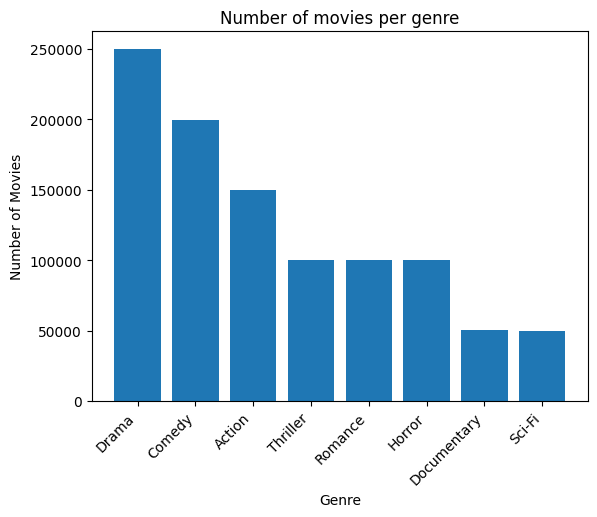

In [23]:
pdf = df.toPandas()
 
plt.figure()
plt.bar(pdf["Genre"], pdf["frequency"])
plt.title("Number of movies per genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.show()

In [24]:
spark.stop()